# Top tagging 

This notebook is dedicated to exploring the dataset and visualizing the features to gain insights into the data distribution and relationships between variables. We will use various plotting techniques to understand the characteristics of the dataset and identify any patterns or anomalies that may be present. 

The 3 main datasets wil be:
- **Top tagging**: This dataset contains information about top quark tagging, which is a technique used in particle physics to identify top quarks in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for top quark identification.
- **Quark-gluon jet tagging**: This dataset contains information about quark-gluon jet tagging, which is a technique used to distinguish between jets originating from quarks and gluons. The features in this dataset may include various jet substructure observables and kinematic variables that are relevant for quark-gluon discrimination.
- **Higgs tagging**: This dataset contains information about Higgs boson tagging, which is a technique used to identify Higgs bosons in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for Higgs boson identification.

We can find the dataset in the following path: `../data/raw/top/val.h5`. We use the val test to not load 1 GB from train set. We will load the dataset and perform some exploratory data analysis to understand the distribution of the features and the relationships between them. We will start by loading the dataset and displaying some basic information about it, such as the number of samples, the number of features, and the distribution of the target variable. We will then create various plots to visualize the data, such as histograms, scatter plots, and correlation matrices. This will help us identify any patterns or anomalies in the data that may be relevant for our analysis.

**Description taken from the original source:** [zenodo](https://zenodo.org/records/2603256)

A set of MC simulated training/testing events for the evaluation of top quark tagging architectures.

In total 1.2M training events, 400k validation events and 400k test events. Use “train” for training, “val” for validation during the training and “test” for final testing and reporting results.

Description

- 14 TeV, hadronic tops for signal, qcd diets background, Delphes ATLAS detector card with Pythia8

- No MPI/pile-up included

- Clustering of  particle-flow entries (produced by Delphes E-flow) into anti-kT 0.8 jets in the pT range [550,650] GeV

- All top jets are matched to a parton-level top within ∆R = 0.8, and to all top decay partons within 0.8

- Jets are required to have |$\eta$| < 2

- The leading 200 jet constituent four-momenta are stored, with zero-padding for jets with fewer than 200

- Constituents are sorted by pT, with the highest pT one first

- The truth top four-momentum is stored as truth_px etc.

- A flag (1 for top, 0 for QCD) is kept for each jet. It is called is_signal_new

- The variable "ttv" (= test/train/validation) is kept for each jet. It indicates to which dataset the jet belongs. It is redundant as the different sets are already distributed as different files.

In [1]:
# Cargamos las librerías necesarias
import h5py
import hdf5plugin
import gc

ModuleNotFoundError: No module named 'h5py'

In [2]:
try:
    with h5py.File('../data/raw/top/val.h5', 'r') as f:
        print("File keys:", list(f.keys()))
        table = f['table']
        print("Table keys:", list(table.keys()))
        
        print("\n_i_table keys:", list(table['_i_table'].keys())) 
        print("table columns:", list(table['table'].dtype.names))

except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

File keys: ['table']
Table keys: ['_i_table', 'table']

_i_table keys: ['index']
table columns: ['index', 'values_block_0', 'values_block_1']


**_i_table key**

In [3]:
try:
    with h5py.File('../data/raw/top/val.h5', 'r') as f:
        table = f['table']['_i_table']['index']
        print("_i_table keys:", list(table.keys()), "\n")
        
        for key in table.keys():
            print(f"{key}: shape {table[key].shape}, dtype {table[key].dtype}")

except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

_i_table keys: ['abounds', 'bounds', 'indices', 'indicesLR', 'mbounds', 'mranges', 'ranges', 'sorted', 'sortedLR', 'zbounds'] 

abounds: shape (384,), dtype int64
bounds: shape (3, 127), dtype int64
indices: shape (3, 131072), dtype uint32
indicesLR: shape (131072,), dtype uint32
mbounds: shape (384,), dtype int64
mranges: shape (3,), dtype int64
ranges: shape (3, 2), dtype int64
sorted: shape (3, 131072), dtype int64
sortedLR: shape (131201,), dtype int64
zbounds: shape (384,), dtype int64


This `_i_table` entry is a list of Optimized Index, so we will focus on `table` entry.

**table key**

In [4]:
try:
    with h5py.File('../data/raw/top/val.h5', 'r') as f:   
        table = f['table']['table']
        print("Table keys:", list(table.dtype.names), "\n")
        
        for key in table.dtype.names:
            print(f"{key}: shape {table[key].shape}, dtype {table[key].dtype}")
except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

Table keys: ['index', 'values_block_0', 'values_block_1'] 

index: shape (403000,), dtype int64
values_block_0: shape (403000, 804), dtype float32
values_block_1: shape (403000, 2), dtype int64


Let's see what is inside of `values_block_0` and `values_block_1`.

In [5]:
del table
gc.collect()

93

## Data exploration

In [6]:
import polars as pl
#import matplotlib.pyplot as plt
#import seaborn as sns
import numpy as np
#import h5py
#import hdf5plugin

The description mentions store the four-momenta of the leading 200 jet constituyents and the four-momenta of the truth top. In order to know which was stored firts lets see the statistic description of the 0 and 800 file.

In [7]:
# Load the data
try:
    with h5py.File('../data/raw/top/val.h5', 'r') as f:
        table = f['table']['table']
        # We take just 100 000 file to this first part
        x_top_data = table['values_block_0'][:]
        y_top_data = table['values_block_1'][:]

        df_comprobation = pl.DataFrame({
            "px_particle_1": x_top_data[:, 0],
            "px_truth_top": x_top_data[:, 800]
        })
        x_df = pl.DataFrame(x_top_data[:100000, :20])
        print(x_df.describe())
        print(df_comprobation.describe())

except Exception as e:
    print(f"Error: {e}")

shape: (9, 21)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ column_0  ┆ column_1  ┆ column_2  ┆ … ┆ column_16 ┆ column_17 ┆ column_18 ┆ column_1 │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ 9        │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 100000.0  ┆ 100000.0  ┆ 100000.0  ┆ … ┆ 100000.0  ┆ 100000.0  ┆ 100000.0  ┆ 100000.0 │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ 232.35685 ┆ 0.420741  ┆ -0.147117 ┆ … ┆ 48.688019 ┆ 0.08361   

We can see zeros in the 800-th column and also bigger energy. This means that the first column is for the first jet constituent, and the 800-th is for the truth top.

Now, let's analice the subparticles.

In [8]:
del df_comprobation, x_df
gc.collect()

0

In [9]:
SEED = 42

## Data visualization

Now let´s see de general distributions of the features.

In [10]:
# import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
# import numpy as np
# import h5py
# import hdf5plugin

In [ ]:
# first rows of y_top_data
print("First rows of y_top_data:")
print(y_top_data[:5])

# Statictic description of y_top_data
print("\nStatictic description of y_top_data:")
print(pl.DataFrame(y_top_data).describe())

We can conclude that the first column of `values_block_1` is for the kind of dataset, 1 for train, 2, for val and 3 for test. the second column is the label, 1 for signal (top) and 0 for background (QCD).

We will take only 50 000 samples to not overload the notebook. We will use a log scale for the energy distribution to better visualize the range of values.

Now let's see the distribution of diferent features for signal and background. We will use histograms to visualize the distributions of the features.

In [12]:
x_sample = x_top_data[:50000, :]
y_sample = y_top_data[:50000, 1]

# Central axis momenta
E_jet = np.sum(x_sample[:, 0:800:4], axis=1)
px_jet = np.sum(x_sample[:, 1:800:4], axis=1)
py_jet = np.sum(x_sample[:, 2:800:4], axis=1)
pz_jet = np.sum(x_sample[:, 3:800:4], axis=1)

# Jet angles
pt_jet = np.sqrt(px_jet**2 + py_jet**2)
eta_jet = -np.log(np.tan(np.arctan2(pt_jet, pz_jet + 1e-12) / 2.0) + 1e-12)
phi_jet = np.arctan2(py_jet, px_jet + 1e-12)

    # Invariant mass calculation with clipping to avoid negative values
mass_sq = np.clip(E_jet**2 - (px_jet**2 + py_jet**2 + pz_jet**2), 0.0, None)
invariant_mass = np.sqrt(mass_sq)

    # Clean up raw jet arrays to free memory
del px_jet, py_jet, pz_jet, E_jet, pt_jet, mass_sq
gc.collect()

# Use jets with invariant mass > 10 GeV to avoid unphysical jets
mass_mask = (invariant_mass > 145.0) & (invariant_mass < 205.0)  # Ensure it's a boolean array
x_sample_cut = x_sample[mass_mask]
y_sample_cut = y_sample[mass_mask]
invariant_mass = invariant_mass[mass_mask]
eta_jet = eta_jet[mass_mask]
phi_jet = phi_jet[mass_mask]
n_events = x_sample.shape[0]

# ----------------------------------------
# 2. Local masking and feature engineering
# ----------------------------------------

# EXTRACT CARTESIAN FLOWS
# we will only consider the first 50 particles for each jet to reduce dimensionality
# in this step, to improve preformance.
# Nevertheless, the raw_matrix has 200 particles (800 columns). In next steps we 
# will dynamically select the number of particles to keep based on the Pareto 80% rule.
n_particles = 75
p_x = x_sample[:, 1:n_particles*4:4]
p_y = x_sample[:, 2:n_particles*4:4]
p_z = x_sample[:, 3:n_particles*4:4]
E   = x_sample[:, 0:n_particles*4:4]
    
pt_block = np.sqrt(p_x**2 + p_y**2)
# Identify ghost particles (pt < 1e-8) to mask them out
# is_ghost = (pt_block < 1e-8)

# CONSTITUENT MASKING (Layer 1)
# Compute particle-level angles and pseudorapidities
#theta_i = np.zeros_like(pt_block)
#eta_i = np.zeros_like(pt_block)
#phi_i = np.zeros_like(pt_block)
    
#idx_real = ~is_ghost
theta_i = np.arctan2(pt_block, p_z + 1e-12)
eta_i = -np.log(np.tan(theta_i / 2.0) + 1e-12)
phi_i = np.arctan2(p_y, p_x + 1e-12)


# Calculate relative coordinates
eta_i = eta_i[mass_mask]
phi_i = phi_i[mass_mask]
d_eta_i = eta_i - eta_jet[:, None]
d_phi_i = np.arctan2(
                np.sin(phi_i - phi_jet[:, None]),
                np.cos(phi_i - phi_jet[:, None])
                )
d_R = np.sqrt(d_eta_i**2 + d_phi_i**2)

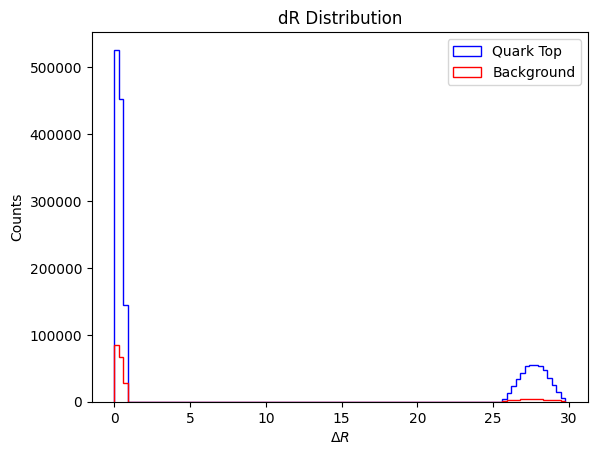

In [13]:
# dR histogram per class
plt.hist(d_R[y_sample_cut == 1].flatten(), bins=100, histtype='step', color='blue', label='Quark Top')
plt.hist(d_R[y_sample_cut == 0].flatten(), bins=100, histtype='step', color='red', label='Background')
plt.xlabel(r'$\Delta R$')
plt.ylabel('Counts')
plt.title('dR Distribution')
#plt.xlim(-0.2,4)
plt.legend()
plt.show()

Something we can see in the graph is the $\Delta R$ shows no cut around 0.8, which is the radius of the jet clustering algorithm. This means that the particles that are outside of this radius are not considered as part of the jet. We need to filter them out. We can also see that the distribution of $\Delta R$ is different for signal and background, but mostly in the same range.

The outliers in the $\Delta R$ distribution are caused for the secure delta added in the calculation of $\Delta R$ to avoid division by zero. We can filter them out by setting a threshold preestablished. We will set the threshold to 0.8 based on the jet clustering algorithm radius. This will help us to focus on the relevant particles that are within the jet radius and improve the analysis of the data.

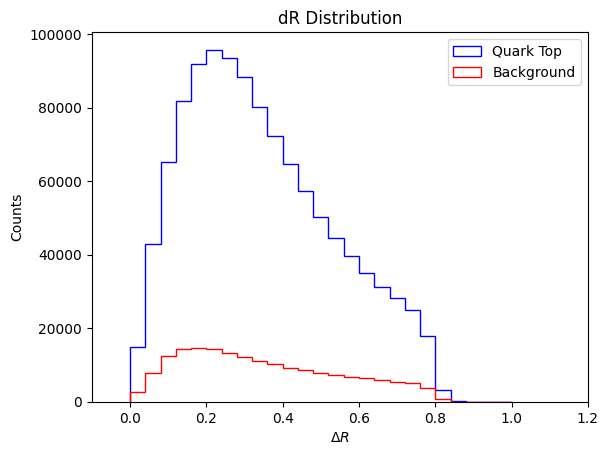

In [15]:
# dR histogram per class
plt.hist(d_R[y_sample_cut == 1].flatten(), bins=25, range=(0, 1), histtype='step', color='blue', label='Quark Top')
plt.hist(d_R[y_sample_cut == 0].flatten(), bins=25, range=(0, 1), histtype='step', color='red', label='Background')
plt.xlabel(r'$\Delta R$')
plt.ylabel('Counts')
plt.title('dR Distribution')
plt.xlim(-0.1,1.2)
plt.legend()
plt.show()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 24081 but size of corresponding boolean axis is 50000

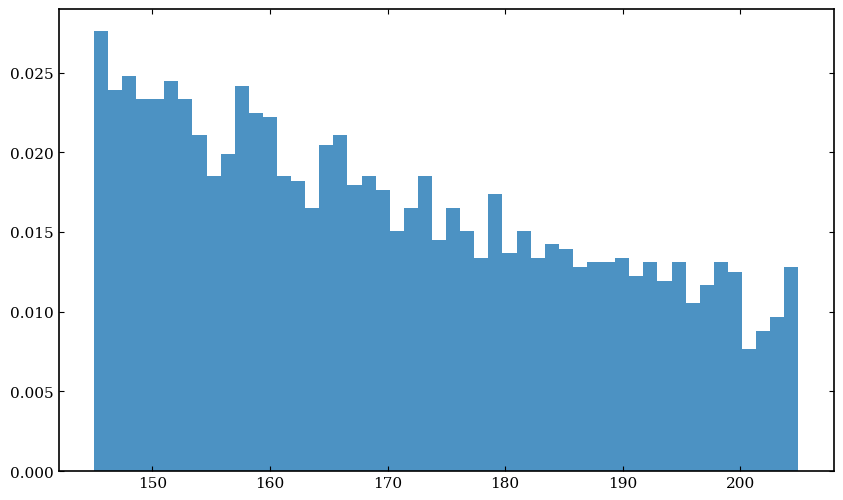

In [35]:
# Normalized Histogram
plt.figure(figsize=(10, 6))
plt.hist(invariant_mass[y_sample_cut == 0], bins= 50, alpha=0.8, label='Background', density=True)
plt.hist(invariant_mass[y_sample_cut == 1], bins= 50, alpha=0.5, label='Quark Top', density=True)
plt.xlabel('Invariant mass (GeV)')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histogram of Invariant Mass by Class')
#plt.xlim(-0.04, 400)
plt.show()

The invariant mass distribution shows a clear separation between signal and background, with the signal peaking around the top quark mass (approximately 173 GeV) and the background having a broader distribution. This indicates that invariant mass is a useful feature for distinguishing between top quark jets and QCD jets. Nevertheless, there is still some overlap between the two distributions, which suggests that additional features may be needed to improve classification performance. An also, we need to normalize the invariant mass distribution to better visualize the differences between signal and background.

In [17]:
# --- Style ---
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "font.family": "serif"
})

# Definition of colors
TOP_COLOR = '#1f77b4'  # Blue for the signal (Hadronic Top)
QCD_COLOR = '#9467bd'  # Purple for the background (QCD Di-jets)

# -------------------------------------------------------------

IndexError: boolean index did not match indexed array along axis 0; size of axis is 24081 but size of corresponding boolean axis is 50000

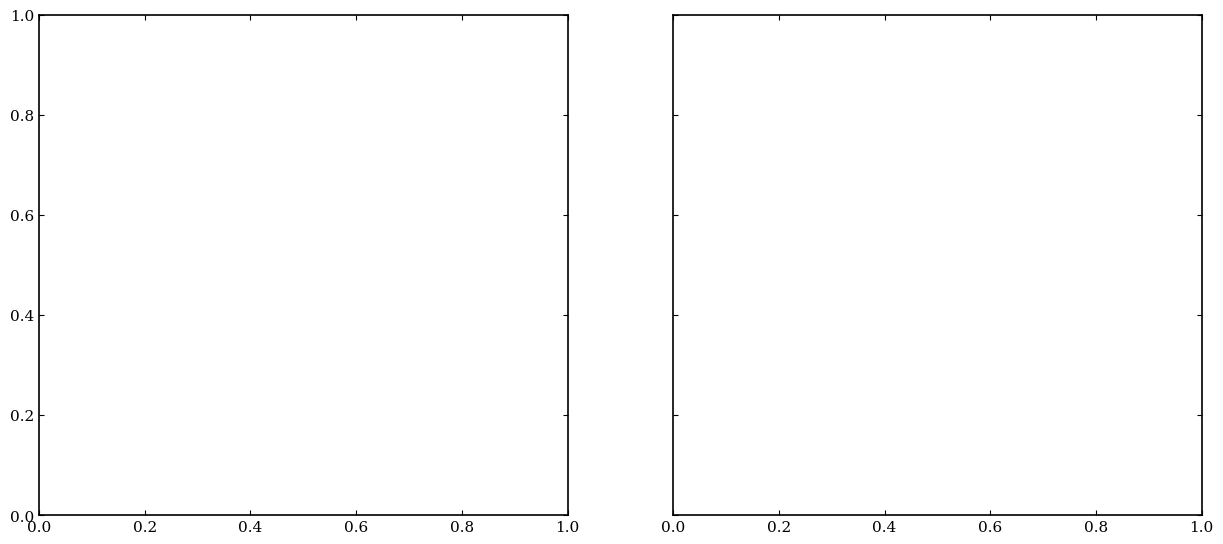

In [18]:
# sig vs bkg
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)
img_range = [[-1.5, 1.5], [-1.5, 1.5]]
bin_resolution = 150

top_delta_eta = d_eta_i[y_sample == 1].flatten()
top_delta_phi = d_phi_i[y_sample == 1].flatten()
bkg_delta_eta = d_eta_i[y_sample == 0].flatten()
bkg_delta_phi = d_phi_i[y_sample == 0].flatten()


# Top quark signal
im0 = axes[0].hist2d(top_delta_eta,
                    top_delta_phi, 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar0 = fig.colorbar(im0[3], ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[0].set_title(r"Signal: Hadronic $t\bar{t}$ Decay (Constituent Density)",
                    fontsize=14,
                    fontweight='bold')
axes[0].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[0].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

# Background
im1 = axes[1].hist2d(bkg_delta_eta, 
                    bkg_delta_phi, 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar1 = fig.colorbar(im1[3], ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[1].set_title("Background: QCD Di-jets (Constituent Density)",
                    fontsize=14,
                    fontweight='bold')
axes[1].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[1].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(img_range[0])
    ax.set_ylim(img_range[1])
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Particle-jet angular differences", fontsize=24, fontweight='bold')
plt.tight_layout()#rect=[0, 0, 1, 0.95])
plt.show()

del top_delta_eta, top_delta_phi, bkg_delta_eta, bkg_delta_phi
del img_range
gc.collect()

This plots shows the dispersión of the particles asociated to the jets in the eta-phi space. We can see that the particles are distributed around the jet axis. We can't see the differences in the dispersion between the top and the QCD, only a probable higher concentration in the background graph. Something we expected since the top quark decays into three particles, while the QCD jet is a single particle, is a greater dispersion of the particles in the eta-phi space for the top quark jets compared to the QCD jets. However, this difference may not be easily visible in the plots due to the scale and range of the axes and also the presence of noise and other factors that can affect the distribution of particles in the eta-phi space. We will need to perform a more detailed analysis to quantify the differences in dispersion between the two types of jets.

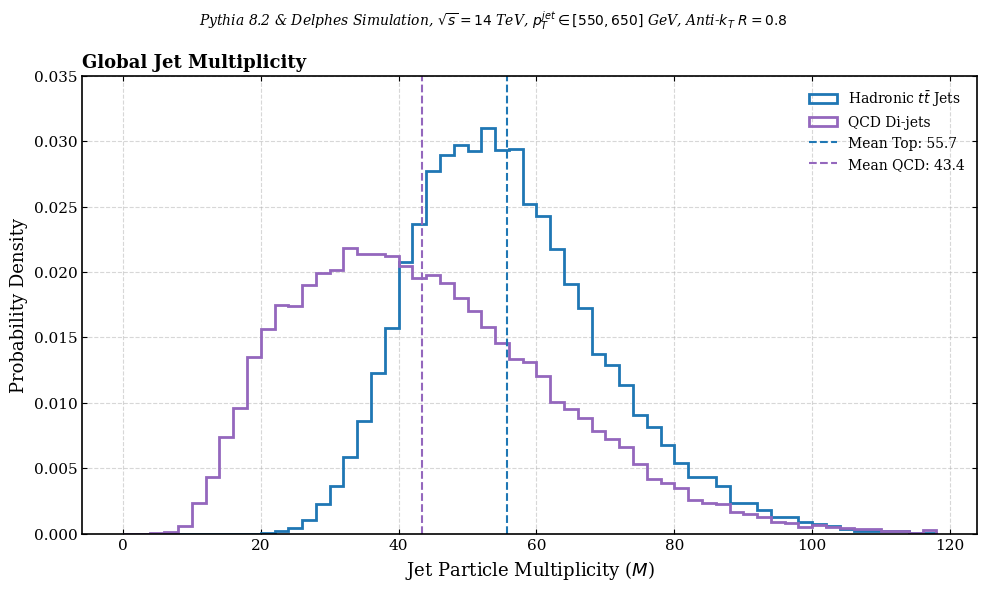

7631

In [19]:
# ==============================================================================
# PANEL 1: GLOBAL EVENT PROPERTIES (2 Subplots)
# ==============================================================================
fig, ax = plt.subplots(1, figsize=(10, 6))

# --- Subplot A: Real Multiplicity Histogram ---
# Count how many constituents with E > 0 each original individual jet has
energy_matrix = x_sample[:, 0::4]
multiplicity_event = np.count_nonzero(energy_matrix > 0, axis=1)

mult_top = multiplicity_event[y_sample == 1]
mult_qcd = multiplicity_event[y_sample == 0]

bins_mult = np.arange(0, 120, 2)
ax.hist(mult_top, bins=bins_mult, histtype="step", lw=2, color=TOP_COLOR, label=r"Hadronic $t\bar{t}$ Jets", density=True)
ax.hist(mult_qcd, bins=bins_mult, histtype="step", lw=2, color=QCD_COLOR, label="QCD Di-jets", density=True)

ax.set_xlabel(r"Jet Particle Multiplicity ($M$)")
ax.set_ylabel("Probability Density")
#ax.set_xlim(0, 110)
ax.set_ylim(0, 0.035)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(frameon=False)
ax.set_title("Global Jet Multiplicity", loc="left", fontweight="bold")

# vertical lines with the mean of each distribution
mean_mult_top = np.mean(mult_top)
mean_mult_qcd = np.mean(mult_qcd)
ax.axvline(mean_mult_top, color=TOP_COLOR, linestyle='--', label=f"Mean Top: {mean_mult_top:.1f}")
ax.axvline(mean_mult_qcd, color=QCD_COLOR, linestyle='--', label=f"Mean QCD: {mean_mult_qcd:.1f}")
ax.legend(frameon=False)

fig.suptitle(r"Pythia 8.2 & Delphes Simulation, $\sqrt{s} = 14$ TeV, $p_T^{jet} \in [550, 650]$ GeV, Anti-$k_T$ $R=0.8$", fontsize=10, y=0.98, style="italic")
plt.tight_layout()
# fig.savefig("panel1_top_global_properties.pdf", dpi=300)
plt.show()

del energy_matrix, multiplicity_event, mult_top, mult_qcd
gc.collect()

With this plot we can see the probability density of the jet multiplicity for the top and QCD jets. We can see that the top jets have a higher multiplicity than the QCD jets, which is expected since the top quark decays into three particles, while the QCD jet is a single particle. The distribution for the top jets is also wider than for the QCD jets, which is also expected since the top quark can decay into different particles with different energies.

The radial energy profile shows how the energy of the jet is distributed as a function of the distance from the jet axis. We can see that the top jets have a more dispersed energy distribution around the jet axis, that is way the curve is more gradual, while the QCD jets have a more concentrated energy distribution around the jet axis, that is why the curve is steeper.

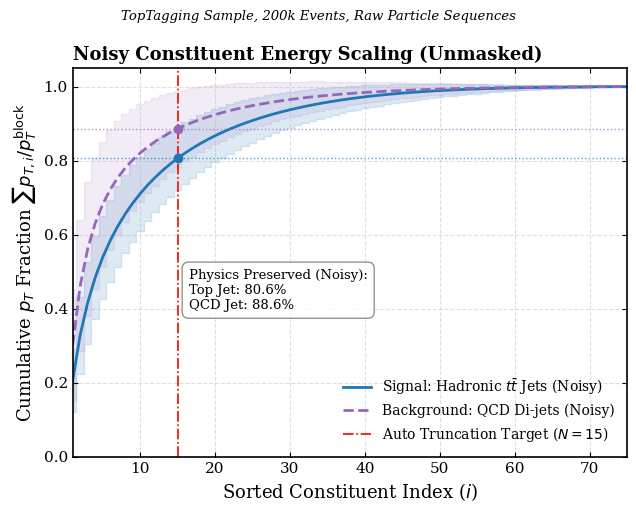

6657

In [20]:
# ==============================================================================
# PARETO KINEMATIC PROCESSING (CON RUIDO)
# ==============================================================================
# Cumulative sum along the particle index (column axis) for the noisy dataset
cumulative_pt = np.cumsum(pt_block, axis=1)

# The last cumulative element (column 50) represents the total pt of the complete Jet
total_pt = cumulative_pt[:, -1]
total_pt_safe = np.where(total_pt == 0, 1.0, total_pt) # Safe against empty jets

# Convert to cumulative fractions (scale 0 to 1)
pt_fraction_matrix = cumulative_pt / total_pt_safe[:, None]

# Segregate the profiles using the true label of the reduced sample (y_sample)
top_profiles = pt_fraction_matrix[y_sample == 1]
qcd_profiles = pt_fraction_matrix[y_sample == 0]

# Calculate mean and standard deviation for each particle index
mean_top = np.mean(top_profiles, axis=0)
std_top = np.std(top_profiles, axis=0)

mean_qcd = np.mean(qcd_profiles, axis=0)
std_qcd = np.std(qcd_profiles, axis=0)

# X axis now goes from 1 to n_particles (50)
particle_indices = np.arange(1, n_particles + 1)

# ==============================================================================
# AUTOMATIC TRUNCATION CALCULATION (80% THRESHOLD)
# ==============================================================================
# Find the first index where BOTH curves exceed 80% (0.8)
both_exceed_80 = (mean_top >= 0.80) & (mean_qcd >= 0.80)

if np.any(both_exceed_80):
    N_cut = int(np.where(both_exceed_80)[0][0] + 1)
else:
    # Safe fallback if noise prevents crossing 80% within the first 50 particles
    N_cut = n_particles 

cut_fraction_top = mean_top[N_cut - 1]
cut_fraction_qcd = mean_qcd[N_cut - 1]

# ==============================================================================
# CONSTRUCTION AND RENDERING OF THE GRAPH
# ==============================================================================

fig, ax = plt.subplots(figsize=(6.5, 5.2))

# Signal Curve (Top Quark) with uncertainty
ax.plot(particle_indices, mean_top, color=TOP_COLOR, lw=2.0, label=r"Signal: Hadronic $t\bar{t}$ Jets (Noisy)")
ax.fill_between(particle_indices, mean_top - std_top, mean_top + std_top, 
                color=TOP_COLOR, alpha=0.15, step="mid")

# Background Curve (QCD) with uncertainty
ax.plot(particle_indices, mean_qcd, color=QCD_COLOR, lw=2.0, label="Background: QCD Di-jets (Noisy)", linestyle="--")
ax.fill_between(particle_indices, mean_qcd - std_qcd, mean_qcd + std_qcd, 
                color=QCD_COLOR, alpha=0.12, step="mid")

# --- TRUNCATION THRESHOLD INDICATORS ---
ax.axhline(y=cut_fraction_top, color=TOP_COLOR, linestyle=':', lw=1.0, alpha=0.7)
ax.axhline(y=cut_fraction_qcd, color=QCD_COLOR, linestyle=':', lw=1.0, alpha=0.7)

ax.axvline(x=N_cut, color='red', linestyle='-.', lw=1.2, 
           label=f"Auto Truncation Target ($N={N_cut}$)")

ax.plot(N_cut, cut_fraction_top, marker='o', color=TOP_COLOR, markersize=6)
ax.plot(N_cut, cut_fraction_qcd, marker='o', color=QCD_COLOR, markersize=6)

# Explanatory text box
physics_text = f"Physics Preserved (Noisy):\nTop Jet: {cut_fraction_top*100:.1f}%\nQCD Jet: {cut_fraction_qcd*100:.1f}%"
ax.text(N_cut + 1.5, 0.40, physics_text, 
        fontsize=9.5, bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.5'))

# --- AXIS FORMATTING ---
ax.set_xlabel("Sorted Constituent Index ($i$)")
ax.set_ylabel(r"Cumulative $p_T$ Fraction $\sum p_{T,i} / p_{T}^{\mathrm{block}}$")

# Dynamic adjustment of X-axis zoom based on the current 50 particles
ax.set_xlim(1, n_particles)
ax.set_ylim(0.0, 1.05)

ax.set_title("Noisy Constituent Energy Scaling (Unmasked)", loc="left", fontweight="bold")
fig.suptitle(r"TopTagging Sample, 200k Events, Raw Particle Sequences", 
             fontsize=9.5, y=0.98, style="italic")

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

del cumulative_pt, total_pt, total_pt_safe, pt_fraction_matrix, top_profiles, qcd_profiles
del mean_top, std_top, mean_qcd, std_qcd, particle_indices
gc.collect()

This plot shows the cumulative energy fraction considering the sorted particles in the jet. We can see that the top jets have a more gradual increase in the cumulative energy fraction, while the QCD jets have a more rapid increase. This indicates that the top jets have a more dispersed energy distribution, while the QCD jets have a more concentrated energy distribution.

This part is important because to avoid use all the particles in the jet and saturate the model.

## Feature engeneering

Now is time to establish how we will process the data for traning. The focus is
1) Use global and local features
2) Truncate the jets to a fixed number of constituents, N_cut, that preserves most of the physics. We will use the cumulative pT distribution to determine the optimal N_cut.
3) Normalize the features to ensure that they are on a similar scale, which can help with the training of the model. 

The global features are those that describe the overall properties of the jet, such as its total energy, mass, and transverse momentum. The local features are those that describe the properties of the individual constituents of the jet, such as their energy, momentum, and position. By using both global and local features, we can capture both the overall characteristics of the jet and the detailed information about its constituents, which can help improve the performance of our model.
For the model we select 
- Jets mass $$m_{jet} = \sqrt{E^2 - p_x^2 - p_y^2 - p_z^2}$$
- Multiplicity of the jet, that is the number of constituents with non-zero energy. We calculate this by counting the number of constituents with energy greater than $1 \times 10^{-8}$.

For the local features, we wil use the spatial coordinates and the relative transverse momentum of the constituents. We will calculate the relative transverse momentum as the ratio of the constituent's transverse momentum to the jet's total transverse momentum from the N_cut leading constituents. This will help us capture the distribution of energy within the jet and how it relates to the overall properties of the jet.
- $\Delta R = \sqrt{(\eta_{i} - \eta_{jet})^2 + (\phi_{i} - \phi_{jet})^2}$
- $p_{T,rel} = \frac{p_{T,i}}{p_{T,\sum N_{cut}}}$

The cumulative pT distribution is a plot that shows the cumulative sum of the transverse momentum (pT) of the jet constituents as a function of the number of constituents. This plot can help us determine the optimal N_cut by showing us how much of the total pT is preserved as we include more constituents. The first try will be the number of particles where the cumulative pT fraction is greater than 80% for both top and QCD jets. This means that we will keep the leading N_cut constituents that preserve at least 80% of the total pT of the jet. Based on the previous plot 

\begin{equation}
    N_{cut} = 15
\end{equation}

With this in mind, all the local features will be in $(0,1)$, we need to normalize the global features. The main diferences between the distributions are in the extreme values, so we will use a log transformation to better visualize the distribution and also to reduce the impact of outliers. We will apply the log transformation to the jet mass, and also we keep the outliers to not lose information about the tails of the distribution, which can be important for the classification task because in the center the distributions are very similar.

After the log transformation, we will use a tanh normalization to scale the features to the range (-1, 1). This will help to ensure that all features are on a similar scale, which can improve the training of the model. Also this avoids the problem of compressing the values in the middle of the distributions.

At this point the code is saved into `src/process/processor_top.py` and the processed data is saved in `data/tt_processed_inputs.npy` and the scaler for the jet mass is saved in `data/scaler_top.pkl`. The processed data contains the following features:
- `m_scaled`: The log-transformed and tanh-normalized jet mass.
- `M_scaled`: The tanh-normalized jet multiplicity.
- `d_R`: The distance of each constituent from the jet axis in the eta-phi space.
- `z_effective`: The relative transverse momentum of each constituent with respect to the first 15 constituents' total transverse momentum.

The first part will be pretty much the same plots but normalized. We will also include the cumulative pT distribution to show how we determined the optimal N_cut.

In [21]:
from sklearn.preprocessing import StandardScaler, RobustScaler
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import gc
import seaborn as sns
import matplotlib.gridspec as GridSpec

In [22]:
x_sample = x_top_data[:50000, :]
y_sample = y_top_data[:50000, 1]

In [23]:
# -------------------------------------------------------------------------
# 1. MÁSCARA GLOBAL Y REDUCCIÓN GEOMÉTRICA INICIAL
# -------------------------------------------------------------------------
# Extraer componentes globales usando vistas vectorizadas (paso ultra rápido)
E_jet   = np.sum(x_sample[:, 0:800:4], axis=1)
px_jet  = np.sum(x_sample[:, 1:800:4], axis=1)
py_jet  = np.sum(x_sample[:, 2:800:4], axis=1)
pz_jet  = np.sum(x_sample[:, 3:800:4], axis=1)

pt_jet  = np.sqrt(px_jet**2 + py_jet**2)
eta_jet = -np.log(np.tan(np.arctan2(pt_jet, pz_jet + 1e-12) / 2.0) + 1e-12)
phi_jet = np.arctan2(py_jet, px_jet + 1e-12)

# Cálculo de masa invariante limpia de valores negativos
mass_sq = np.clip(E_jet**2 - (px_jet**2 + py_jet**2 + pz_jet**2), 0.0, None)
invariant_mass = np.sqrt(mass_sq)

del px_jet, py_jet, pz_jet, E_jet, pt_jet, mass_sq
gc.collect()

# Filtro cinemático global del Jet (Masa Invariante > 10 GeV)
mass_mask = (invariant_mass > 145.0) & (invariant_mass < 205.0)  # Ensure it's a boolean array
invariant_mass = invariant_mass[mass_mask]
eta_jet = eta_jet[mass_mask]
phi_jet = phi_jet[mass_mask]
    
# Extraemos la multiplicidad cruda global antes de truncar la matriz
multiplicity = np.sum(x_sample[mass_mask, 0:800:4] > 1e-3, axis=1)
n_events = invariant_mass.shape[0]

# Reducción de dimensionalidad controlada a 100 partículas (Ventana Óptima)
n_initial_particles = 100
    
# Extraemos bloques en RAM (copia local para no alterar el dataset original)
E_block  = x_sample[mass_mask, 0:n_initial_particles*4:4].copy()
px_block = x_sample[mass_mask, 1:n_initial_particles*4:4].copy()
py_block = x_sample[mass_mask, 2:n_initial_particles*4:4].copy()
pz_block = x_sample[mass_mask, 3:n_initial_particles*4:4].copy()

# -------------------------------------------------------------------------
# PASO 1 Y 2: IDENTIFICACIÓN DE FANTASMAS Y CLONACIÓN GEOMÉTRICA (EVITAR TELEPORT)
# -------------------------------------------------------------------------
pt_block = np.sqrt(px_block**2 + py_block**2)
del px_block, py_block
gc.collect()

# Máscara booleana ligera de partículas reales
is_real = pt_block >= 1e-3

# Inicialización controlada: Heredan las coordenadas exactas del eje del jet
eta_i = np.repeat(eta_jet[:, None], n_initial_particles, axis=1)
phi_i = np.repeat(phi_jet[:, None], n_initial_particles, axis=1)

# Cálculo angular exclusivo para componentes reales
theta_real = np.arctan2(pt_block[is_real], pz_block[is_real] + 1e-12)
eta_i[is_real] = -np.log(np.tan(theta_real / 2.0) + 1e-12)
phi_i[is_real] = np.arctan2(x_sample[mass_mask, 2:n_initial_particles*4:4][is_real], 
                                x_sample[mass_mask, 1:n_initial_particles*4:4][is_real] + 1e-12)
    
del pz_block, theta_real, E_block
gc.collect()

# -------------------------------------------------------------------------
# PASO 3: DISTANCIA MINKOWSKI RELATIVA SIN ARTEFACTOS ASIMÉTRICOS
# -------------------------------------------------------------------------
d_eta_i = eta_i - eta_jet[:, None]
d_phi_i = np.arctan2(np.sin(phi_i - phi_jet[:, None]), np.cos(phi_i - phi_jet[:, None]))
    
# Gracias a la clonación, los fantasmas dan exactamente 0.0 de forma natural
d_R = np.sqrt(d_eta_i**2 + d_phi_i**2)

del  eta_i, phi_i#, d_eta_i, d_phi_i
gc.collect()

# -------------------------------------------------------------------------
# PASO 4: FILTRO DE VIABILIDAD FÍSICA IN-PLACE (PULVERIZACIÓN POR DETECTOR)
# -------------------------------------------------------------------------
# Criterio: Fuera del cono (> 0.80) O fuera del calorímetro (|eta| >= 3.0)
# Nota: Volvemos a calcular el eta real temporalmente para el corte del detector
eta_check = np.repeat(eta_jet[:, None], n_initial_particles, axis=1)
eta_check[is_real] = -np.log(np.tan(np.arctan2(pt_block[is_real], x_sample[mass_mask, 3:n_initial_particles*4:4][is_real] + 1e-12) / 2.0) + 1e-12)
    
unphysical_mask = (d_R > 0.80) | (np.abs(eta_check) >= 3.0) | (~is_real)
    
# Pulverización In-place instantánea
pt_block[unphysical_mask] = 0.0
#d_R[unphysical_mask] = 0.0

del eta_check, is_real, unphysical_mask
gc.collect()

# -------------------------------------------------------------------------
# PASO 5: ORDENAMIENTO SINCRONIZADO DE ALTA VELOCIDAD
# -------------------------------------------------------------------------
# Obtenemos los índices para ordenar de mayor a menor p_T por fila
sort_indices = np.argsort(-pt_block, axis=1)
    
# Reordenamiento síncronizado in-place vía advanced indexing masivo
row_indices = np.arange(n_events)[:, None]
pt_block = pt_block[row_indices, sort_indices]
d_R = d_R[row_indices, sort_indices]

del sort_indices, row_indices
gc.collect()

# -------------------------------------------------------------------------
# PASO 6: AMPUTACIÓN DINÁMICA POR PARETO (UMBRAL DEL 80% ENERGÍA)
# -------------------------------------------------------------------------
pt_cumsum = np.cumsum(pt_block, axis=1)
pt_total_cone = pt_cumsum[:, -1]
    
# Evitar divisiones por cero en jets vacíos
pt_total_cone_safe = np.where(pt_total_cone <= 0, 1.0, pt_total_cone)
pt_frac_cumsum = pt_cumsum / pt_total_cone_safe[:, None]

# Índice donde acumulamos el 80% del p_T efectivo del cono
idx_80 = np.argmax(pt_frac_cumsum >= 0.80, axis=1) + 1
n_particles = int(np.percentile(idx_80, 90))
n_particles = max(n_particles, 5)  # Respetar el piso físico mínimo de estabilidad

# Amputación masiva por rebanado (Extirpación de memoria ruidosa sobrante)
pt_block = pt_block[:, :n_particles]
d_R = d_R[:, :n_particles]

# -------------------------------------------------------------------------
# CALCULO DE VARIABLES FINALES (Z-EFFECTIVE)
# -------------------------------------------------------------------------
sum_pt_final = np.sum(pt_block, axis=1)
sum_pt_final_safe = np.where(sum_pt_final <= 0, 1.0, sum_pt_final)
z_effective = pt_block / sum_pt_final_safe[:, None]

del pt_cumsum, pt_frac_cumsum, sum_pt_final, sum_pt_final_safe#, pt_block
gc.collect()

y_filter = y_sample[mass_mask]

# -------------------------------------------------------------------------
# COMPRESIÓN ASÍNTOTICA Y EMPAQUETADO (OUTPUT PARA KAN)
# -------------------------------------------------------------------------
m_log = np.log(invariant_mass + 1.0)

robust_scaler = RobustScaler()
m_robust = robust_scaler.fit_transform(m_log.reshape(-1, 1)).flatten()

m_scaled = np.tanh(m_robust)
del m_log, m_robust
gc.collect()

#del invariant_mass
scaler = None  # Placeholder for the scaler object, can be set externally if needed
if scaler is None:
    scaler = StandardScaler()
    M_robust = scaler.fit_transform(multiplicity.reshape(-1, 1)).flatten()
else:
    M_robust = scaler.transform(multiplicity.reshape(-1, 1)).flatten()

sigma_max = 3
    
M_cliped = np.clip(M_robust, -sigma_max, sigma_max)
M_scaled = M_cliped / sigma_max

del M_robust
gc.collect()

# Asignación de memoria en bloque único para la matriz procesada final
processed_matrix = np.zeros((n_events, 2 + 2 * n_particles), dtype=np.float32)
processed_matrix[:, 0] = m_scaled
processed_matrix[:, 1] = M_scaled

# Intercalado eficiente mediante strides/rebanado (eliminando bucles lentos)
processed_matrix[:, 2::2] = d_R
processed_matrix[:, 3::2] = z_effective

#del d_R, z_effective
del sigma_max, m_scaled, M_scaled, M_cliped
gc.collect()

0

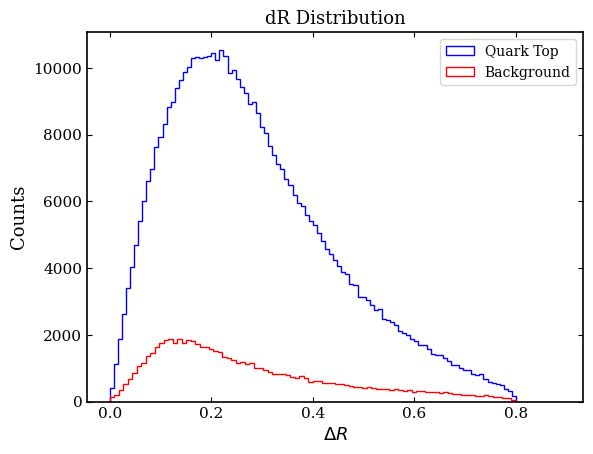

In [24]:
# dR histogram per class
plt.hist(processed_matrix[y_filter == 1][:, 2::2].flatten(), bins=100, histtype='step', color='blue', label='Quark Top')
plt.hist(processed_matrix[y_filter == 0][:, 2::2].flatten(), bins=100, histtype='step', color='red', label='Background')
plt.xlabel(r'$\Delta R$')
plt.ylabel('Counts')
plt.title('dR Distribution')
#plt.xlim(0.996,1.0005)
plt.legend()
plt.show()

In [25]:
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch

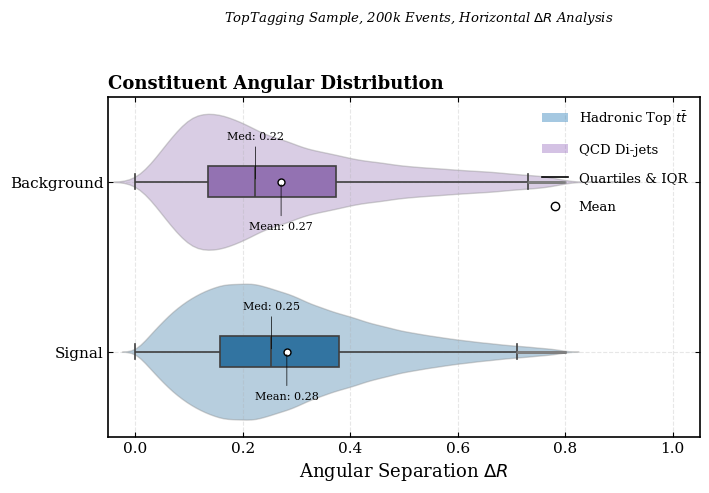

11368

In [26]:
# ==============================================================================
# DATA EXTRACTION & PROCESSING
# ==============================================================================
dR_top = processed_matrix[y_filter == 1][:, 2::2].flatten()
dR_bkg = processed_matrix[y_filter == 0][:, 2::2].flatten()

df_dR = pd.DataFrame({
    'dR': np.concatenate([dR_top, dR_bkg]),
    'Class': [r'Signal'] * len(dR_top) + [r'Background'] * len(dR_bkg)
})

# Calculate exact statistics for text injection
means = df_dR.groupby('Class')['dR'].mean()
medians = df_dR.groupby('Class')['dR'].median()

# ==============================================================================
# CONSTRUCTION AND RENDERING OF THE HORIZONTAL HYBRID PLOT
# ==============================================================================
# Aspect ratio optimized for horizontal layout
fig, ax = plt.subplots(figsize=(8.5, 5.0))

# 1. --- Bottom layer: Violin Plot Horizontal (orient='h') ---
sns.violinplot(
    x='dR', 
    y='Class', 
    data=df_dR,
    hue='Class',
    legend=False,
    palette=[TOP_COLOR, QCD_COLOR],
    orient='h',
    inner=None,          
    bw_method='silverman',    
    linewidth=1.0,
    edgecolor='gray',
    alpha=0.35,          
    ax=ax
)

# 2. --- Top layer: Box Plot Horizontal (orient='h') ---
meanprops = {'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':5}
#dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=5, zorder=4)
flierprops = dict(marker='.', markersize=2, alpha=0.1, markeredgecolor='gray')

sns.boxplot(
    x='dR',
    y='Class',
    data=df_dR,
    hue='Class',
    legend=False,
    palette=[TOP_COLOR, QCD_COLOR],
    orient='h',
    showmeans=True,
    meanprops=meanprops,
    flierprops=flierprops,
    width=0.18,          
    linewidth=1.2,
    ax=ax
)

# 3. --- STATISTICAL VALUES (Mean and Median) ---
# Since the plot is horizontal, we iterate over the positions of the Y-axis (0 and 1)
classes_ordered = [r'Signal', r'Background']

for i, cls in enumerate(classes_ordered):
    y_pos = i
    # Label for Median (above)
    ax.annotate(f'Med: {medians[cls]:.2f}', xy=(medians[cls], y_pos), 
                xytext=(medians[cls], y_pos + 0.25), fontsize=8, ha='center', 
                arrowprops=dict(arrowstyle='-', color='black', lw=0.5))
    # Label for Mean (below)
    ax.annotate(f'Mean: {means[cls]:.2f}', xy=(means[cls], y_pos), 
                xytext=(means[cls], y_pos - 0.28), fontsize=8, ha='center', 
                arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

# 4. --- LEGEND ---
legend_handles = [
    Patch(facecolor=TOP_COLOR, alpha=0.4, edgecolor='none', label=r'Hadronic Top $t\bar{t}$'),
    Patch(facecolor=QCD_COLOR, alpha=0.4, edgecolor='none', label='QCD Di-jets'),
    plt.Line2D([0], [0], color='black', lw=1.2, label='Quartiles & IQR'),
    plt.Line2D([0], [0], marker='o', color='black', markerfacecolor='white', markersize=6, linestyle='None', label='Mean')
]
ax.legend(handles=legend_handles,
            loc='upper right',
            frameon=False,
            fontsize=9.5,
            bbox_to_anchor=(1.0, 1.0),
            labelspacing=1.2
)

# --- AXIS FORMATTING ---
ax.set_xlabel(r"Angular Separation $\Delta R$")
ax.set_ylabel("")

ax.set_xlim(-0.05, 1.05) 
ax.set_ylim(-0.5, 1.5)

# HEP style titles
ax.set_title("Constituent Angular Distribution", loc="left", fontweight="bold")
fig.suptitle(r"TopTagging Sample, 200k Events, Horizontal $\Delta R$ Analysis", 
             fontsize=9.5, y=0.98, style="italic")

ax.grid(True, linestyle="--", alpha=0.3, zorder=0)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

# ==============================================================================
# CLEANUP
# ==============================================================================
del (dR_top, 
    dR_bkg, 
    df_dR, 
    means, 
    medians,
    fig,
    ax,
    meanprops,
    flierprops,
    legend_handles,
    classes_ordered)
gc.collect()

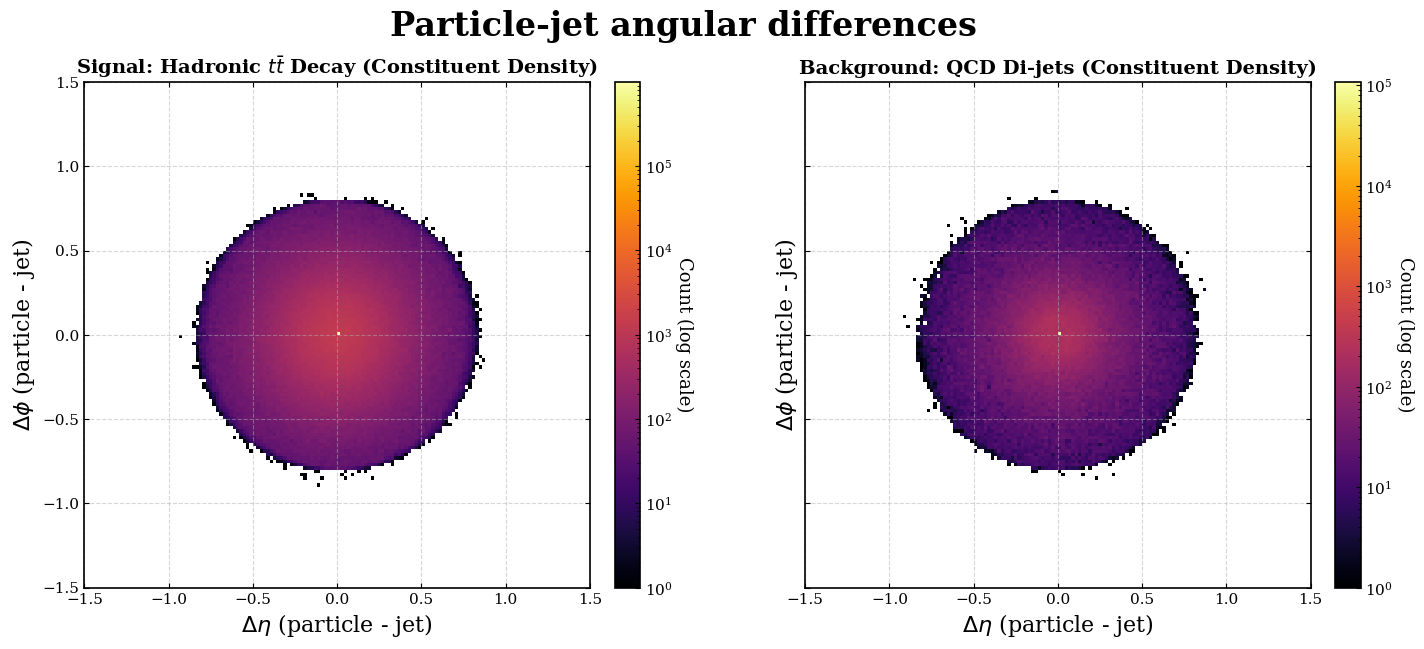

12499

In [27]:
# sig vs bkg
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)
img_range = [[-1.5, 1.5], [-1.5, 1.5]]
bin_resolution = 150

top_delta_eta = d_eta_i[y_filter == 1].flatten()
top_delta_phi = d_phi_i[y_filter == 1].flatten()
bkg_delta_eta = d_eta_i[y_filter == 0].flatten()
bkg_delta_phi = d_phi_i[y_filter == 0].flatten()


# Top quark signal
im0 = axes[0].hist2d(top_delta_eta,
                    top_delta_phi, 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar0 = fig.colorbar(im0[3], ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[0].set_title(r"Signal: Hadronic $t\bar{t}$ Decay (Constituent Density)",
                    fontsize=14,
                    fontweight='bold')
axes[0].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[0].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

# Background
im1 = axes[1].hist2d(bkg_delta_eta, 
                    bkg_delta_phi, 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar1 = fig.colorbar(im1[3], ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[1].set_title("Background: QCD Di-jets (Constituent Density)",
                    fontsize=14,
                    fontweight='bold')
axes[1].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[1].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(img_range[0])
    ax.set_ylim(img_range[1])
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Particle-jet angular differences", fontsize=24, fontweight='bold')
plt.tight_layout()#rect=[0, 0, 1, 0.95])
plt.show()

del (top_delta_eta,
    top_delta_phi,
    bkg_delta_eta,
    bkg_delta_phi,
    img_range,
    fig,
    axes,
    im0,
    im1,
    cbar0,
    cbar1,
    bin_resolution)
gc.collect()

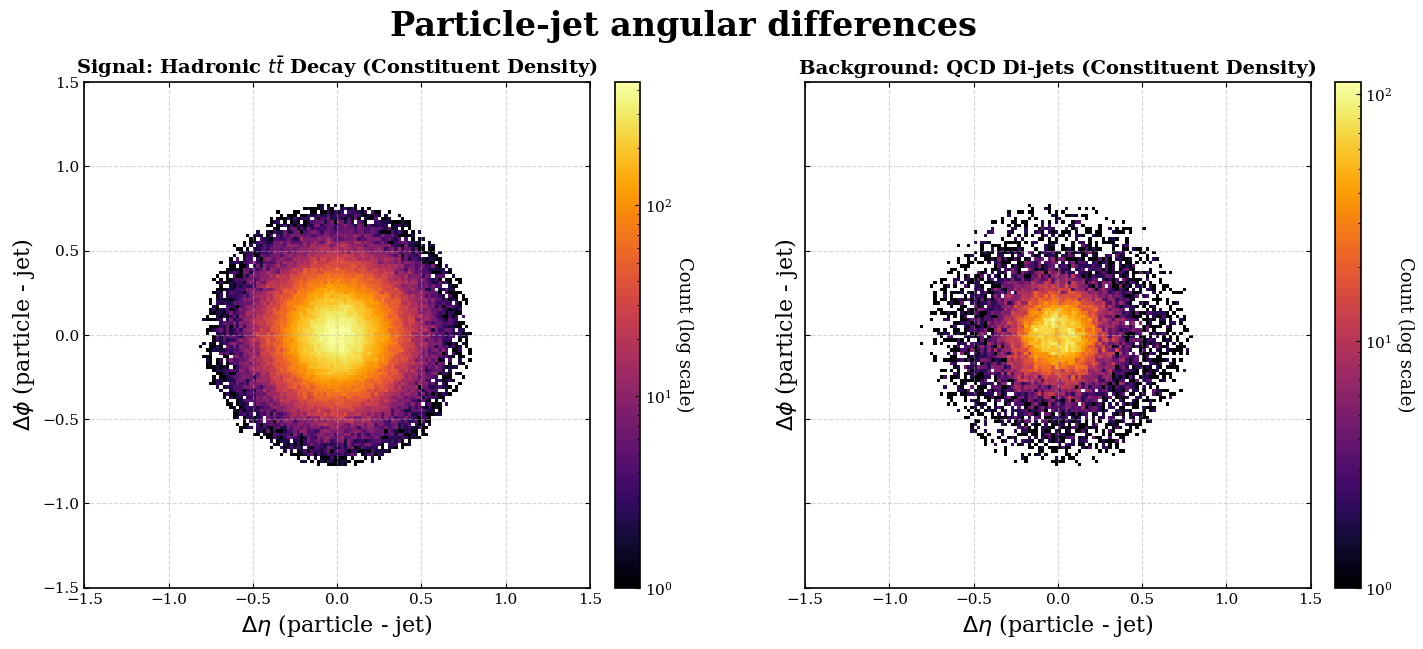

28199

In [28]:
# sig vs bkg
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)
img_range = [[-1.5, 1.5], [-1.5, 1.5]]
bin_resolution = 150

top_delta_eta = d_eta_i[y_filter == 1][:, :10].flatten()
top_delta_phi = d_phi_i[y_filter == 1][:, :10].flatten()
bkg_delta_eta = d_eta_i[y_filter == 0][:, :10].flatten()
bkg_delta_phi = d_phi_i[y_filter == 0][:, :10].flatten()


# Top quark signal
im0 = axes[0].hist2d(top_delta_eta,
                    top_delta_phi, 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar0 = fig.colorbar(im0[3], ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[0].set_title(r"Signal: Hadronic $t\bar{t}$ Decay (Constituent Density)",
                    fontsize=14,
                    fontweight='bold')
axes[0].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[0].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

# Background
im1 = axes[1].hist2d(bkg_delta_eta, 
                    bkg_delta_phi, 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar1 = fig.colorbar(im1[3], ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[1].set_title("Background: QCD Di-jets (Constituent Density)",
                    fontsize=14,
                    fontweight='bold')
axes[1].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[1].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(img_range[0])
    ax.set_ylim(img_range[1])
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Particle-jet angular differences", fontsize=24, fontweight='bold')
plt.tight_layout()#rect=[0, 0, 1, 0.95])
plt.show()

del (top_delta_eta,
    top_delta_phi,
    bkg_delta_eta,
    bkg_delta_phi,
    img_range,
    fig,
    axes,
    im0,
    im1,
    cbar0,
    cbar1,
    bin_resolution)
gc.collect()

In [29]:
from matplotlib.gridspec import GridSpec

/tmp/ipykernel_165175/3117798209.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_yticklabels(["QCD\n(Bkg)", "Top\n(Signal)"], fontsize=11)


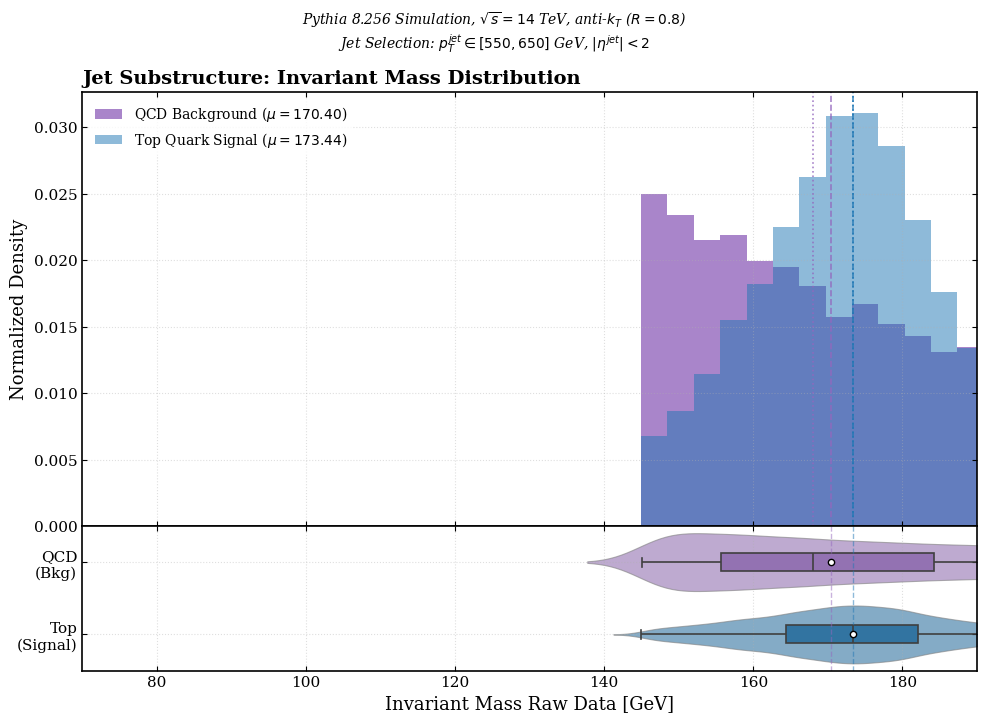

21710

In [30]:
# ==============================================================================
# 2. Extract invariant mass
# ==============================================================================
# Invariant Mass
mass_bkg = invariant_mass[y_filter == 0]
mass_top = invariant_mass[y_filter == 1]

# Key statistics for vertical lines and labels
mean_bkg, median_bkg = mass_bkg.mean(), np.median(mass_bkg)
mean_top, median_top = mass_top.mean(), np.median(mass_top)

# ==============================================================================
# 3. CREATE HYBRID CANVAS (GridSpec)
# ==============================================================================
fig = plt.figure(figsize=(10.0, 7.5))

# 3 parts for the PDF Histogram, 1 part for the Box/Violin block
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.00)

ax_hist = fig.add_subplot(gs[0])
ax_box = fig.add_subplot(gs[1], sharex=ax_hist)

# ==============================================================================
# 4. UPPER PANEL: DENSITY HISTOGRAMS (STEP)
# ==============================================================================
bins_mass = np.linspace(0.0, 350.0, 100)

# Histograms
ax_hist.hist(
    mass_bkg,
    bins=bins_mass,
    #histtype="step",
    lw=2.0,
    color=QCD_COLOR,
    density=True,
    label=rf"QCD Background ($\mu={mean_bkg:.2f}$)",
    alpha=0.8
)
ax_hist.hist(
    mass_top,
    bins=bins_mass,
    #histtype="step",
    lw=2.0,
    color=TOP_COLOR,
    density=True,
    label=rf"Top Quark Signal ($\mu={mean_top:.2f}$)",
    alpha=0.5
)

# Guide lines for Means and Medians
ax_hist.axvline(mean_bkg, color=QCD_COLOR, linestyle="--", lw=1.2, alpha=0.8)
ax_hist.axvline(median_bkg, color=QCD_COLOR, linestyle=":", lw=1.2, alpha=0.8)
ax_hist.axvline(mean_top, color=TOP_COLOR, linestyle="--", lw=1.2, alpha=0.8)
ax_hist.axvline(median_top, color=TOP_COLOR, linestyle=":", lw=1.2, alpha=0.8)

# Format the upper panel
ax_hist.set_ylabel("Normalized Density", fontsize=13)
ax_hist.set_title(
    "Jet Substructure: Invariant Mass Distribution",
    loc="left",
    fontweight="bold",
    fontsize=14,
)
ax_hist.legend(frameon=True, facecolor="white", edgecolor="none", loc="upper left")
ax_hist.grid(True, linestyle=":", alpha=0.4)

# Hide x-axis labels of the histogram to avoid overlap with the boxplot
plt.setp(ax_hist.get_xticklabels(), visible=False)

# ==============================================================================
# 5. LOWER PANEL: HYBRID BOXPLOTS AND VIOLINPLOTS
# ==============================================================================
# Temporary data structuring for Seaborn
df_box = pd.DataFrame({
    "Mass": np.concatenate([mass_bkg, mass_top]),
    "Class": ["QCD (Bkg)"] * len(mass_bkg) + ["Top (Signal)"] * len(mass_top),
})

# Smooth Violin layer to see the continuous background distribution
sns.violinplot(
    x="Mass",
    y="Class",
    data=df_box,
    hue="Class",
    legend=False,
    palette=[QCD_COLOR, TOP_COLOR],
    orient="h",
    inner=None,
    bw_method="silverman",
    linewidth=0.8,
    edgecolor="gray",
    alpha=0.60,
    ax=ax_box,
)

# Minimalist Boxplot layer
meanprops = {
    "marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black",
    "markersize": 4.5,
}
flierprops = dict(marker=".", markersize=1.5, alpha=0.02, markeredgecolor="gray")

sns.boxplot(
    x="Mass",
    y="Class",
    data=df_box,
    hue="Class",
    legend=False,
    palette=[QCD_COLOR, TOP_COLOR],
    orient="h",
    showmeans=True,
    meanprops=meanprops,
    flierprops=flierprops,
    width=0.25,
    linewidth=1.2,
    ax=ax_box,
)

# Replicate trend lines in the boxplot for visual consistency
ax_box.axvline(mean_bkg, color=QCD_COLOR, linestyle="--", lw=1.0, alpha=0.5)
ax_box.axvline(mean_top, color=TOP_COLOR, linestyle="--", lw=1.0, alpha=0.5)

# Format the lower panel
ax_box.set_xlabel(r"Invariant Mass Raw Data [GeV]", fontsize=13)
ax_box.set_ylabel("")
ax_box.set_yticklabels(["QCD\n(Bkg)", "Top\n(Signal)"], fontsize=11)
ax_box.set_xlim(70.0, 190.0)
ax_box.grid(True, linestyle=":", alpha=0.4)

# ==============================================================================
# 6. EXPERIMENT METADATA (HEP STYLE)
# ==============================================================================
fig.suptitle(
    r"Pythia 8.256 Simulation, $\sqrt{s} = 14$ TeV, anti-$k_T$ ($R=0.8$)"
    "\n"
    r"Jet Selection: $p_T^{jet} \in [550, 650]$ GeV, $|\eta^{jet}| < 2$",# $M_{\text{invariant}} > 10.0$ GeV",
    fontsize=10,
    y=0.96,
    style="italic",
    ha="center",
    fontfamily="serif"
)

plt.tight_layout()
plt.subplots_adjust(top=0.85) # Space for the suptitle without collisions
plt.show()

# ==============================================================================
# 7. TOTAL MEMORY CLEANUP
# ==============================================================================
del (df_box,
    mass_bkg,
    mass_top,
    mean_bkg,
    median_bkg,
    mean_top,
    median_top,
    fig,
    gs,
    ax_hist,
    ax_box,
    bins_mass,
    meanprops,
    flierprops)
gc.collect()

/tmp/ipykernel_165175/3983737718.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_yticklabels(["QCD\n(Bkg)", "Top\n(Signal)"], fontsize=11)


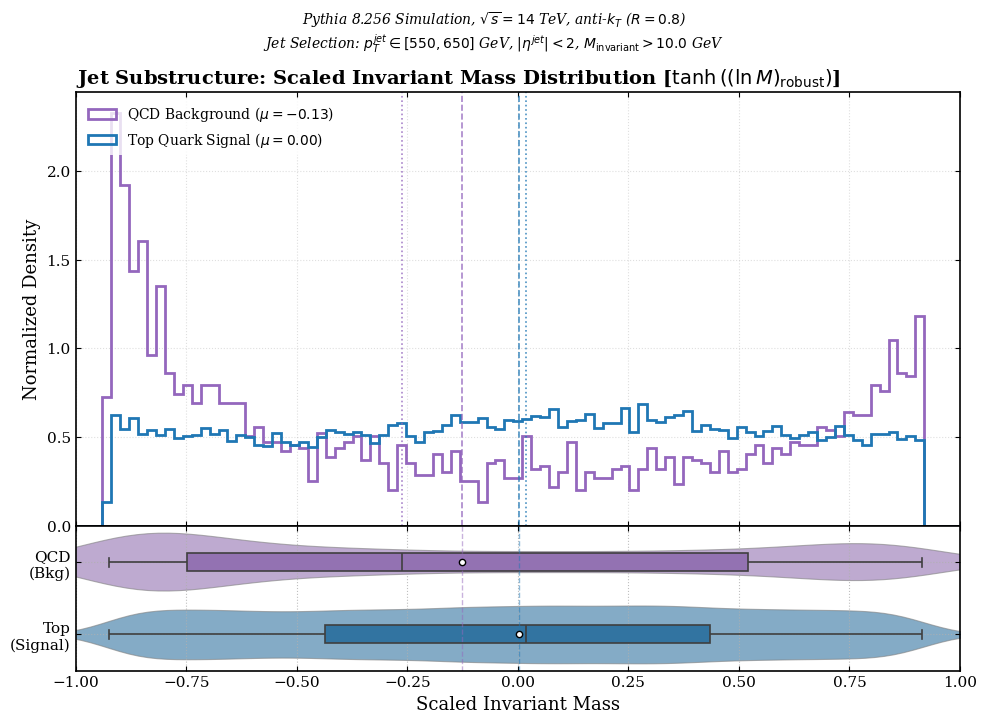

9782

In [31]:
# ==============================================================================
# 2. EXTRACT VARIABLES FROM PROCESSED MATRIX
# ==============================================================================
# Extract column 0 (Scaled Invariant Mass with np.tanh)
mass_scaled_bkg = processed_matrix[y_filter == 0][:, 0]
mass_scaled_top = processed_matrix[y_filter == 1][:, 0]

# Key statistics for vertical lines and labels
mean_bkg, median_bkg = mass_scaled_bkg.mean(), np.median(mass_scaled_bkg)
mean_top, median_top = mass_scaled_top.mean(), np.median(mass_scaled_top)

# ==============================================================================
# 3. CREATE HYBRID CANVAS (GridSpec)
# ==============================================================================
fig = plt.figure(figsize=(10.0, 7.5))

# 3 parts for the PDF Histogram, 1 part for the Box/Violin block
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.00)

ax_hist = fig.add_subplot(gs[0])
ax_box = fig.add_subplot(gs[1], sharex=ax_hist)

# ==============================================================================
# 4. UPPER PANEL: DENSITY HISTOGRAMS (STEP)
# ==============================================================================
bins_mass = np.linspace(-1.0, 1.0, 100)

# Histograms using the 'step' line style
ax_hist.hist(
    mass_scaled_bkg,
    bins=bins_mass,
    histtype="step",
    lw=2.0,
    color=QCD_COLOR,
    density=True,
    label=rf"QCD Background ($\mu={mean_bkg:.2f}$)",
)
ax_hist.hist(
    mass_scaled_top,
    bins=bins_mass,
    histtype="step",
    lw=2.0,
    color=TOP_COLOR,
    density=True,
    label=rf"Top Quark Signal ($\mu={mean_top:.2f}$)",
)

# Guide lines for Means and Medians
ax_hist.axvline(mean_bkg, color=QCD_COLOR, linestyle="--", lw=1.2, alpha=0.8)
ax_hist.axvline(median_bkg, color=QCD_COLOR, linestyle=":", lw=1.2, alpha=0.8)
ax_hist.axvline(mean_top, color=TOP_COLOR, linestyle="--", lw=1.2, alpha=0.8)
ax_hist.axvline(median_top, color=TOP_COLOR, linestyle=":", lw=1.2, alpha=0.8)

# Format the upper panel
ax_hist.set_ylabel("Normalized Density", fontsize=13)
ax_hist.set_title(
    r"Jet Substructure: Scaled Invariant Mass Distribution [$\tanh \left( (\ln M)_{\text{robust}} \right)$]",
    loc="left",
    fontweight="bold",
    fontsize=14,
)
ax_hist.legend(frameon=True, facecolor="white", edgecolor="none", loc="upper left")
ax_hist.grid(True, linestyle=":", alpha=0.4)

# Hide x-axis labels of the histogram to avoid overlap with the boxplot
plt.setp(ax_hist.get_xticklabels(), visible=False)

# ==============================================================================
# 5. LOWER PANEL: HYBRID BOXPLOTS AND VIOLINPLOTS
# ==============================================================================
# Temporary data structuring for Seaborn
df_box = pd.DataFrame({
    "Mass": np.concatenate([mass_scaled_bkg, mass_scaled_top]),
    "Class": ["QCD (Bkg)"] * len(mass_scaled_bkg) + ["Top (Signal)"] * len(mass_scaled_top),
})

# Smooth Violin layer to see the continuous background distribution
sns.violinplot(
    x="Mass",
    y="Class",
    data=df_box,
    hue="Class",
    legend=False,
    palette=[QCD_COLOR, TOP_COLOR],
    orient="h",
    inner=None,
    bw_method="silverman",
    linewidth=0.8,
    edgecolor="gray",
    alpha=0.60,
    ax=ax_box,
)

# Minimalist Boxplot layer
meanprops = {
    "marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black",
    "markersize": 4.5,
}
flierprops = dict(marker=".", markersize=1.5, alpha=0.02, markeredgecolor="gray")

sns.boxplot(
    x="Mass",
    y="Class",
    data=df_box,
    hue="Class",
    legend=False,
    palette=[QCD_COLOR, TOP_COLOR],
    orient="h",
    showmeans=True,
    meanprops=meanprops,
    flierprops=flierprops,
    width=0.25,
    linewidth=1.2,
    ax=ax_box,
)

# Replicate trend lines in the boxplot for visual consistency
ax_box.axvline(mean_bkg, color=QCD_COLOR, linestyle="--", lw=1.0, alpha=0.5)
ax_box.axvline(mean_top, color=TOP_COLOR, linestyle="--", lw=1.0, alpha=0.5)

# Format the lower panel
ax_box.set_xlabel(r"Scaled Invariant Mass", fontsize=13)
ax_box.set_ylabel("")
ax_box.set_yticklabels(["QCD\n(Bkg)", "Top\n(Signal)"], fontsize=11)
ax_box.set_xlim(-1.0, 1.0)  # Strict limit of the hyperbolic tangent space
ax_box.grid(True, linestyle=":", alpha=0.8)

# ==============================================================================
# 6. EXPERIMENT METADATA (HEP STYLE)
# ==============================================================================
fig.suptitle(
    r"Pythia 8.256 Simulation, $\sqrt{s} = 14$ TeV, anti-$k_T$ ($R=0.8$)"
    "\n"
    r"Jet Selection: $p_T^{jet} \in [550, 650]$ GeV, $|\eta^{jet}| < 2$, $M_{\text{invariant}} > 10.0$ GeV",
    fontsize=10,
    y=0.96,
    style="italic",
    ha="center",
    fontfamily="serif"
)

plt.tight_layout()
plt.subplots_adjust(top=0.85) # Space for the suptitle without collisions
plt.show()

# ==============================================================================
# 7. TOTAL MEMORY CLEANUP
# ==============================================================================
del (df_box,
    mass_scaled_bkg,
    mass_scaled_top,
    mean_bkg,
    median_bkg,
    mean_top,
    median_top,
    fig,
    gs,
    ax_hist,
    ax_box,
    bins_mass,
    meanprops,
    flierprops)
gc.collect()

/tmp/ipykernel_165175/4189959004.py:127: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_yticklabels(["QCD\n(Bkg)", "Top\n(Signal)"], fontsize=11)


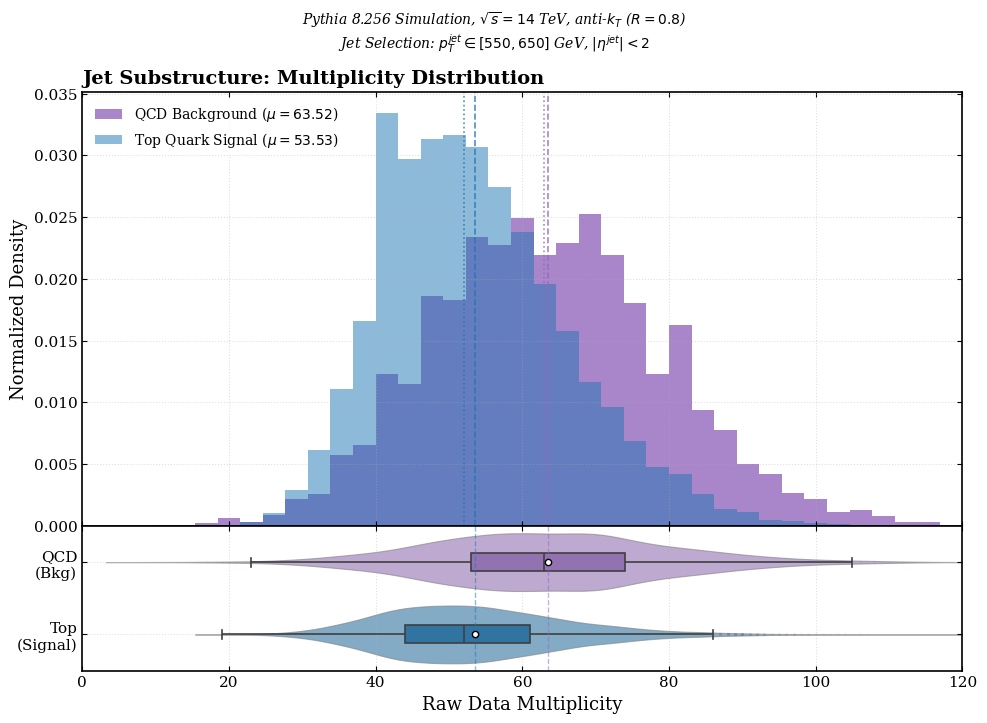

2149

In [32]:
# ==============================================================================
# 2. Multiplicity
# ==============================================================================
mass_bkg = multiplicity[y_filter == 0]
mass_top = multiplicity[y_filter == 1]

# Key Statistics for vertical lines and labels
mean_bkg, median_bkg = mass_bkg.mean(), np.median(mass_bkg)
mean_top, median_top = mass_top.mean(), np.median(mass_top)

# ==============================================================================
# 3. CREATION OF THE HYBRID CANVAS (GridSpec)
# ==============================================================================
fig = plt.figure(figsize=(10.0, 7.5))

# 3 parts for the PDF Histogram, 1 part for the Box/Violin block
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.00)

ax_hist = fig.add_subplot(gs[0])
ax_box = fig.add_subplot(gs[1], sharex=ax_hist)

# ==============================================================================
# 4. UPPER PANEL: DENSITY HISTOGRAMS (STEP)
# ==============================================================================
bins_mass = np.linspace(0.0, 120.0, 40)

# Histograms
ax_hist.hist(
    mass_bkg,
    bins=bins_mass,
    #histtype="step",
    lw=2.0,
    color=QCD_COLOR,
    density=True,
    label=rf"QCD Background ($\mu={mean_bkg:.2f}$)",
    alpha=0.8
)
ax_hist.hist(
    mass_top,
    bins=bins_mass,
    #histtype="step",
    lw=2.0,
    color=TOP_COLOR,
    density=True,
    label=rf"Top Quark Signal ($\mu={mean_top:.2f}$)",
    alpha=0.5
)

# Guide lines for Means and Medians
ax_hist.axvline(mean_bkg, color=QCD_COLOR, linestyle="--", lw=1.2, alpha=0.8)
ax_hist.axvline(median_bkg, color=QCD_COLOR, linestyle=":", lw=1.2, alpha=0.8)
ax_hist.axvline(mean_top, color=TOP_COLOR, linestyle="--", lw=1.2, alpha=0.8)
ax_hist.axvline(median_top, color=TOP_COLOR, linestyle=":", lw=1.2, alpha=0.8)

# Upper panel formatting
ax_hist.set_ylabel("Normalized Density", fontsize=13)
ax_hist.set_title(
    "Jet Substructure: Multiplicity Distribution",
    loc="left",
    fontweight="bold",
    fontsize=14,
)
ax_hist.legend(frameon=True, facecolor="white", edgecolor="none", loc="upper left")
ax_hist.grid(True, linestyle=":", alpha=0.4)

# Hide X-axis labels of the histogram to avoid overlap with the boxplot
plt.setp(ax_hist.get_xticklabels(), visible=False)

# ==============================================================================
# 5. LOWER PANEL: HYBRID BOXPLOTS AND VIOLINPLOTS
# ==============================================================================
# Temporary data structuring for Seaborn
df_box = pd.DataFrame({
    "Multiplicity": np.concatenate([mass_bkg, mass_top]),
    "Class": ["QCD (Bkg)"] * len(mass_bkg) + ["Top (Signal)"] * len(mass_top),
})

# Smooth Violin layer to see the continuous background distribution
sns.violinplot(
    x="Multiplicity",
    y="Class",
    data=df_box,
    hue="Class",
    legend=False,
    palette=[QCD_COLOR, TOP_COLOR],
    orient="h",
    inner=None,
    bw_method="silverman",
    linewidth=0.8,
    edgecolor="gray",
    alpha=0.60,
    ax=ax_box,
)

# Minimalist Boxplot layer
meanprops = {
    "marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black",
    "markersize": 4.5,
}
flierprops = dict(marker=".", markersize=1.5, alpha=0.02, markeredgecolor="gray")

sns.boxplot(
    x="Multiplicity",
    y="Class",
    data=df_box,
    hue="Class",
    legend=False,
    palette=[QCD_COLOR, TOP_COLOR],
    orient="h",
    showmeans=True,
    meanprops=meanprops,
    flierprops=flierprops,
    width=0.25,
    linewidth=1.2,
    ax=ax_box,
)

# Replicate trend lines in the boxplot for visual consistency
ax_box.axvline(mean_bkg, color=QCD_COLOR, linestyle="--", lw=1.0, alpha=0.5)
ax_box.axvline(mean_top, color=TOP_COLOR, linestyle="--", lw=1.0, alpha=0.5)

# Lower panel formatting
ax_box.set_xlabel(r"Raw Data Multiplicity", fontsize=13)
ax_box.set_ylabel("")
ax_box.set_yticklabels(["QCD\n(Bkg)", "Top\n(Signal)"], fontsize=11)
ax_box.set_xlim(0.0, 120.0)
ax_box.grid(True, linestyle=":", alpha=0.4)

# ==============================================================================
# 6. EXPERIMENT METADATA (HEP STYLE)
# ==============================================================================
fig.suptitle(
    r"Pythia 8.256 Simulation, $\sqrt{s} = 14$ TeV, anti-$k_T$ ($R=0.8$)"
    "\n"
    r"Jet Selection: $p_T^{jet} \in [550, 650]$ GeV, $|\eta^{jet}| < 2$",# $M_{\text{invariant}} > 1.0$ GeV",
    fontsize=10,
    y=0.96,
    style="italic",
    ha="center",
    fontfamily="serif"
)

plt.tight_layout()
plt.subplots_adjust(top=0.85) # Space for the suptitle without collisions
plt.show()

# ==============================================================================
# 7. TOTAL MEMORY CLEANUP
# ==============================================================================
del df_box, mass_bkg, mass_top
gc.collect()

/tmp/ipykernel_165175/2684921968.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_yticklabels(["QCD\n(Bkg)", "Top\n(Signal)"], fontsize=11)


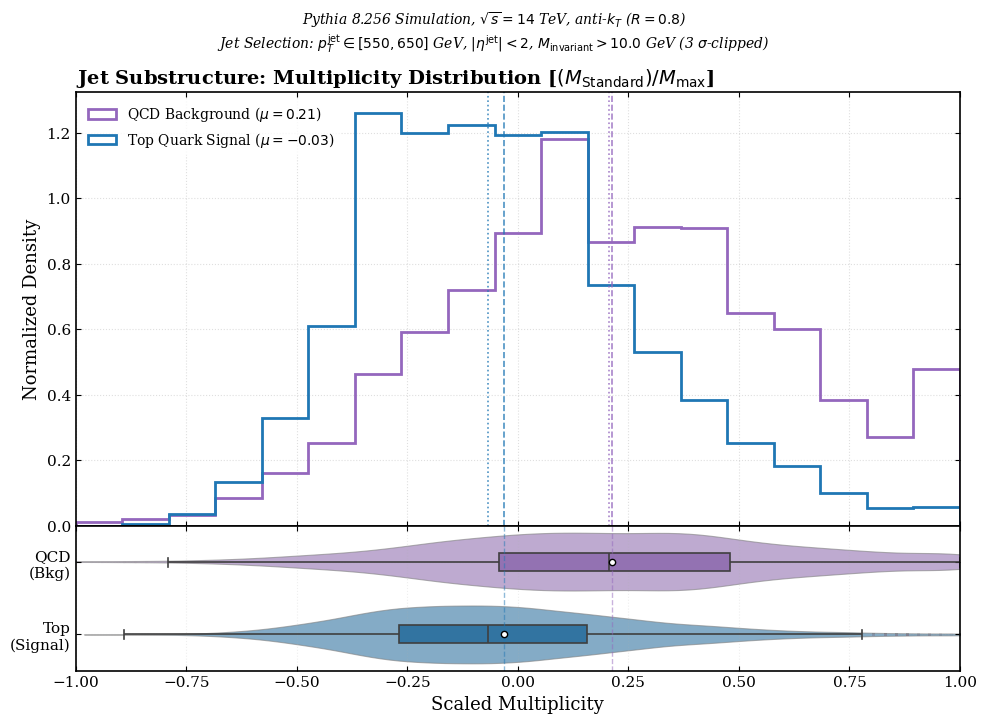

14313

In [33]:
# ==============================================================================
# 2. EXTRACCIÓN DE VECTORES DE LA MATRIZ PROCESADA
# ==============================================================================
# Extraemos la columna 0 (Masa Invariante Escalada con np.tanh)
mass_bkg = processed_matrix[y_filter == 0][:, 1]
mass_top = processed_matrix[y_filter == 1][:, 1]

# Estadísticos clave para las líneas verticales y etiquetas
mean_bkg, median_bkg = mass_bkg.mean(), np.median(mass_bkg)
mean_top, median_top = mass_top.mean(), np.median(mass_top)

# ==============================================================================
# 3. CREACIÓN DEL CANVAS HÍBRIDO (GridSpec)
# ==============================================================================
fig = plt.figure(figsize=(10.0, 7.5))

# 3 partes para el Histograma PDF, 1 parte para el bloque Box/Violin
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.00)

ax_hist = fig.add_subplot(gs[0])
ax_box = fig.add_subplot(gs[1], sharex=ax_hist)

# ==============================================================================
# 4. PANEL SUPERIOR: HISTOGRAMAS DENSIDAD (STEP)
# ==============================================================================
bins_mass = np.linspace(-1.0, 1.0, 20)

# Histogramas usando el estilo de línea 'step' limpio
ax_hist.hist(
    mass_bkg,
    bins=bins_mass,
    histtype="step",
    lw=2.0,
    color=QCD_COLOR,
    density=True,
    label=rf"QCD Background ($\mu={mean_bkg:.2f}$)",
    #alpha=0.8
)
ax_hist.hist(
    mass_top,
    bins=bins_mass,
    histtype="step",
    lw=2.0,
    color=TOP_COLOR,
    density=True,
    label=rf"Top Quark Signal ($\mu={mean_top:.2f}$)",
    #alpha=0.5
)

# Líneas guía de Medias y Medianas
ax_hist.axvline(mean_bkg, color=QCD_COLOR, linestyle="--", lw=1.2, alpha=0.8)
ax_hist.axvline(median_bkg, color=QCD_COLOR, linestyle=":", lw=1.2, alpha=0.8)
ax_hist.axvline(mean_top, color=TOP_COLOR, linestyle="--", lw=1.2, alpha=0.8)
ax_hist.axvline(median_top, color=TOP_COLOR, linestyle=":", lw=1.2, alpha=0.8)

# Formato del panel superior
ax_hist.set_ylabel("Normalized Density", fontsize=13)
ax_hist.set_title(
    r"Jet Substructure: Multiplicity Distribution [$(M_{\text{Standard}}) / M_{\text{max}}$]",
    loc="left",
    fontweight="bold",
    fontsize=14,
)
ax_hist.legend(frameon=True, facecolor="white", edgecolor="none", loc="upper left")
ax_hist.grid(True, linestyle=":", alpha=0.4)

# Ocultar etiquetas del eje X del histograma para que no se encimen con el boxplot
plt.setp(ax_hist.get_xticklabels(), visible=False)

# ==============================================================================
# 5. PANEL INFERIOR: BOXPLOTS Y VIOLINPLOTS HÍBRIDOS
# ==============================================================================
# Estructuración temporal de datos para Seaborn
df_box = pd.DataFrame({
    "Multiplicity": np.concatenate([mass_bkg, mass_top]),
    "Class": ["QCD (Bkg)"] * len(mass_bkg) + ["Top (Signal)"] * len(mass_top),
})

# Capa de Violín suave para ver la distribución continua de fondo
sns.violinplot(
    x="Multiplicity",
    y="Class",
    data=df_box,
    hue="Class",
    legend=False,
    palette=[QCD_COLOR, TOP_COLOR],
    orient="h",
    inner=None,
    bw_method="silverman",
    linewidth=0.8,
    edgecolor="gray",
    alpha=0.60,
    ax=ax_box,
)

# Capa de Boxplot minimalista
meanprops = {
    "marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black",
    "markersize": 4.5,
}
flierprops = dict(marker=".", markersize=1.5, alpha=0.02, markeredgecolor="gray")

sns.boxplot(
    x="Multiplicity",
    y="Class",
    data=df_box,
    hue="Class",
    legend=False,
    palette=[QCD_COLOR, TOP_COLOR],
    orient="h",
    showmeans=True,
    meanprops=meanprops,
    flierprops=flierprops,
    width=0.25,
    linewidth=1.2,
    ax=ax_box,
)

# Replicar las líneas de tendencia en el boxplot para coherencia visual
ax_box.axvline(mean_bkg, color=QCD_COLOR, linestyle="--", lw=1.0, alpha=0.5)
ax_box.axvline(mean_top, color=TOP_COLOR, linestyle="--", lw=1.0, alpha=0.5)

# Formato del panel inferior
ax_box.set_xlabel(r"Scaled Multiplicity", fontsize=13)
ax_box.set_ylabel("")
ax_box.set_yticklabels(["QCD\n(Bkg)", "Top\n(Signal)"], fontsize=11)
ax_box.set_xlim(-1.0, 1.0)  # Limite estricto del espacio de la tangente hiperbólica
ax_box.grid(True, linestyle=":", alpha=0.2)

# ==============================================================================
# 6. METADATOS DEL EXPERIMENTO (ESTILO HEP)
# ==============================================================================
fig.suptitle(
    r"Pythia 8.256 Simulation, $\sqrt{s} = 14$ TeV, anti-$k_T$ ($R=0.8$)"
    "\n"
    r"Jet Selection: $p_T^{\text{jet}} \in [550, 650]$ GeV, $|\eta^{\text{jet}}| < 2$, $M_{\text{invariant}} > 10.0$ GeV (3 $\sigma$-clipped)",
    fontsize=10,
    y=0.96,
    style="italic",
    ha="center",
    fontfamily="serif"
)

plt.tight_layout()
plt.subplots_adjust(top=0.85) # Espacio para el suptitle sin colisiones
plt.show()

# ==============================================================================
# 7. LIMPIEZA TOTAL DE MEMORIA
# ==============================================================================
del df_box, mass_bkg, mass_top
gc.collect()

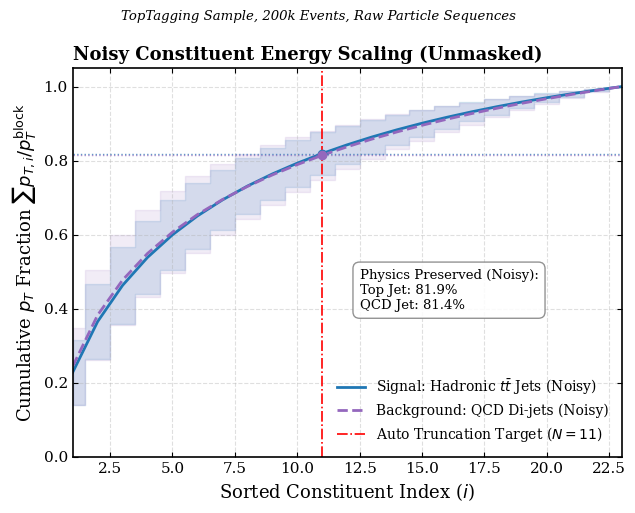

22477

In [34]:
# ==============================================================================
# PARETO KINEMATIC PROCESSING (CON RUIDO)
# ==============================================================================
# Cumulative sum along the particle index (column axis) for the noisy dataset
cumulative_pt = np.cumsum(pt_block, axis=1)

# The last cumulative element (column 50) represents the total pt of the complete Jet
total_pt = cumulative_pt[:, -1]
total_pt_safe = np.where(total_pt == 0, 1.0, total_pt) # Safe against empty jets

# Convert to cumulative fractions (scale 0 to 1)
pt_fraction_matrix = cumulative_pt / total_pt_safe[:, None]

# Segregate the profiles using the true label of the reduced sample (y_filter)
top_profiles = pt_fraction_matrix[y_filter == 1]
qcd_profiles = pt_fraction_matrix[y_filter == 0]

# Calculate mean and standard deviation for each particle index
mean_top = np.mean(top_profiles, axis=0)
std_top = np.std(top_profiles, axis=0)

mean_qcd = np.mean(qcd_profiles, axis=0)
std_qcd = np.std(qcd_profiles, axis=0)

# X axis now goes from 1 to n_particles (50)
particle_indices = np.arange(1, n_particles + 1)

# ==============================================================================
# AUTOMATIC TRUNCATION CALCULATION (80% THRESHOLD)
# ==============================================================================
# Find the first index where BOTH curves exceed 80% (0.8)
both_exceed_80 = (mean_top >= 0.80) & (mean_qcd >= 0.80)

if np.any(both_exceed_80):
    N_cut = int(np.where(both_exceed_80)[0][0] + 1)
else:
    # Safe fallback if noise prevents crossing 80% within the first 50 particles
    N_cut = n_particles 

cut_fraction_top = mean_top[N_cut - 1]
cut_fraction_qcd = mean_qcd[N_cut - 1]

# ==============================================================================
# CONSTRUCTION AND RENDERING OF THE GRAPH
# ==============================================================================

fig, ax = plt.subplots(figsize=(6.5, 5.2))

# Signal Curve (Top Quark) with uncertainty
ax.plot(particle_indices, mean_top, color=TOP_COLOR, lw=2.0, label=r"Signal: Hadronic $t\bar{t}$ Jets (Noisy)")
ax.fill_between(particle_indices, mean_top - std_top, mean_top + std_top, 
                color=TOP_COLOR, alpha=0.15, step="mid")

# Background Curve (QCD) with uncertainty
ax.plot(particle_indices, mean_qcd, color=QCD_COLOR, lw=2.0, label="Background: QCD Di-jets (Noisy)", linestyle="--")
ax.fill_between(particle_indices, mean_qcd - std_qcd, mean_qcd + std_qcd, 
                color=QCD_COLOR, alpha=0.12, step="mid")

# --- TRUNCATION THRESHOLD INDICATORS ---
ax.axhline(y=cut_fraction_top, color=TOP_COLOR, linestyle=':', lw=1.0, alpha=0.7)
ax.axhline(y=cut_fraction_qcd, color=QCD_COLOR, linestyle=':', lw=1.0, alpha=0.7)

ax.axvline(x=N_cut, color='red', linestyle='-.', lw=1.2, 
           label=f"Auto Truncation Target ($N={N_cut}$)")

ax.plot(N_cut, cut_fraction_top, marker='o', color=TOP_COLOR, markersize=6)
ax.plot(N_cut, cut_fraction_qcd, marker='o', color=QCD_COLOR, markersize=6)

# Explanatory text box
physics_text = f"Physics Preserved (Noisy):\nTop Jet: {cut_fraction_top*100:.1f}%\nQCD Jet: {cut_fraction_qcd*100:.1f}%"
ax.text(N_cut + 1.5, 0.40, physics_text, 
        fontsize=9.5, bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.5'))

# --- AXIS FORMATTING ---
ax.set_xlabel("Sorted Constituent Index ($i$)")
ax.set_ylabel(r"Cumulative $p_T$ Fraction $\sum p_{T,i} / p_{T}^{\mathrm{block}}$")

# Dynamic adjustment of X-axis zoom based on the current 50 particles
ax.set_xlim(1, n_particles)
ax.set_ylim(0.0, 1.05)

ax.set_title("Noisy Constituent Energy Scaling (Unmasked)", loc="left", fontweight="bold")
fig.suptitle(r"TopTagging Sample, 200k Events, Raw Particle Sequences", 
             fontsize=9.5, y=0.98, style="italic")

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

del cumulative_pt, total_pt, total_pt_safe, pt_fraction_matrix, top_profiles, qcd_profiles
del mean_top, std_top, mean_qcd, std_qcd, particle_indices
gc.collect()

In [ ]:
# ==============================================================================
# PARETO KINEMATIC PROCESSING (CON RUIDO)
# ==============================================================================
# Cumulative sum along the particle index (column axis) for the noisy dataset
cumulative_pt = np.cumsum(pt_block, axis=1)

# The last cumulative element (column 50) represents the total pt of the complete Jet
total_pt = cumulative_pt[:, -1]
total_pt_safe = np.where(total_pt == 0, 1.0, total_pt) # Safe against empty jets

# Convert to cumulative fractions (scale 0 to 1)
pt_fraction_matrix = cumulative_pt / total_pt_safe[:, None]

# Segregate the profiles using the true label of the reduced sample (y_filter)
top_profiles = pt_fraction_matrix[y_filter == 1]
qcd_profiles = pt_fraction_matrix[y_filter == 0]

# Calculate mean and standard deviation for each particle index
mean_top = np.mean(top_profiles, axis=0)
std_top = np.std(top_profiles, axis=0)

mean_qcd = np.mean(qcd_profiles, axis=0)
std_qcd = np.std(qcd_profiles, axis=0)

# X axis now goes from 1 to n_particles (50)
particle_indices = np.arange(1, n_particles + 1)

# ==============================================================================
# AUTOMATIC TRUNCATION CALCULATION (80% THRESHOLD)
# ==============================================================================
# Find the first index where BOTH curves exceed 80% (0.8)
both_exceed_80 = (mean_top >= 0.80) & (mean_qcd >= 0.80)

if np.any(both_exceed_80):
    N_cut = int(np.where(both_exceed_80)[0][0] + 1)
else:
    # Safe fallback if noise prevents crossing 80% within the first 50 particles
    N_cut = n_particles 

cut_fraction_top = mean_top[N_cut - 1]
cut_fraction_qcd = mean_qcd[N_cut - 1]

# ==============================================================================
# CONSTRUCTION AND RENDERING OF THE GRAPH
# ==============================================================================

fig, ax = plt.subplots(figsize=(6.5, 5.2))

# Signal Curve (Top Quark) with uncertainty
ax.plot(particle_indices, mean_top, color=TOP_COLOR, lw=2.0, label=r"Signal: Hadronic $t\bar{t}$ Jets (Noisy)")
ax.fill_between(particle_indices, mean_top - std_top, mean_top + std_top, 
                color=TOP_COLOR, alpha=0.15, step="mid")

# Background Curve (QCD) with uncertainty
ax.plot(particle_indices, mean_qcd, color=QCD_COLOR, lw=2.0, label="Background: QCD Di-jets (Noisy)", linestyle="--")
ax.fill_between(particle_indices, mean_qcd - std_qcd, mean_qcd + std_qcd, 
                color=QCD_COLOR, alpha=0.12, step="mid")

# --- TRUNCATION THRESHOLD INDICATORS ---
ax.axhline(y=cut_fraction_top, color=TOP_COLOR, linestyle=':', lw=1.0, alpha=0.7)
ax.axhline(y=cut_fraction_qcd, color=QCD_COLOR, linestyle=':', lw=1.0, alpha=0.7)

ax.axvline(x=N_cut, color='red', linestyle='-.', lw=1.2, 
           label=f"Auto Truncation Target ($N={N_cut}$)")

ax.plot(N_cut, cut_fraction_top, marker='o', color=TOP_COLOR, markersize=6)
ax.plot(N_cut, cut_fraction_qcd, marker='o', color=QCD_COLOR, markersize=6)

# Explanatory text box
physics_text = f"Physics Preserved (Noisy):\nTop Jet: {cut_fraction_top*100:.1f}%\nQCD Jet: {cut_fraction_qcd*100:.1f}%"
ax.text(N_cut + 1.5, 0.40, physics_text, 
        fontsize=9.5, bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.5'))

# --- AXIS FORMATTING ---
ax.set_xlabel("Sorted Constituent Index ($i$)")
ax.set_ylabel(r"Cumulative $p_T$ Fraction $\sum p_{T,i} / p_{T}^{\mathrm{block}}$")

# Dynamic adjustment of X-axis zoom based on the current 50 particles
ax.set_xlim(1, n_particles)
ax.set_ylim(0.0, 1.05)

ax.set_title("Noisy Constituent Energy Scaling (Unmasked)", loc="left", fontweight="bold")
fig.suptitle(r"TopTagging Sample, 200k Events, Raw Particle Sequences", 
             fontsize=9.5, y=0.98, style="italic")

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

del cumulative_pt, total_pt, total_pt_safe, pt_fraction_matrix, top_profiles, qcd_profiles
del mean_top, std_top, mean_qcd, std_qcd, particle_indices
gc.collect()